Código para a obter a lista de tickers que já participaram do S&P 500.

Listas Iniciais

In [ ]:
import pandas as pd
import requests

# URL da página da Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

# Ler tabelas
tables = pd.read_html(response.text, header=[0, 1])  # <- pega os dois níveis do cabeçalho

# Empresas atuais
df_current = tables[0][["Symbol", "Security"]].copy()
df_current.columns = ["Ticker", "Security"]
df_current["Status"] = "current"

# Histórico de mudanças (com MultiIndex)
df_changes = tables[1]

# Achatar os nomes de coluna (ex: ("Added","Ticker") -> "Added_Ticker")
df_changes.columns = ['_'.join(col).strip() for col in df_changes.columns.values]

# "Added" -> Ticker e Security
df_added = df_changes[["Added_Ticker", "Added_Security"]].copy()
df_added.columns = ["Ticker", "Security"]
df_added["Status"] = "added"

# "Removed" -> Ticker e Security
df_removed = df_changes[["Removed_Ticker", "Removed_Security"]].copy()
df_removed.columns = ["Ticker", "Security"]
df_removed["Status"] = "removed"

# Concatenar tudo
df_all = pd.concat([df_current, df_added, df_removed], ignore_index=True)

# Remover duplicados
df_all = df_all.dropna(subset=["Ticker"]).drop_duplicates()
df_all = df_all.dropna(subset=["Ticker"]).drop_duplicates(subset=["Ticker"], keep="first")
df_all.loc[df_all["Status"] != "current", "Status"] = "removed"
df_all = df_all.sort_values("Ticker").reset_index(drop=True)
df_all.to_csv("sp500_historical_list.csv", index=False)

print(df_all.head(20))

Filtrar tickers válidos

In [ ]:
import yfinance as yf
import pandas as pd

# Ler CSV
df_all = pd.read_csv("sp500_historical_list.csv")

# Lista de tickers
tickers = df_all["Ticker"].tolist()

# Função para testar se o ticker é válido
def check_ticker(ticker):
    try:
        data = yf.Ticker(ticker).history(period="1d")
        return not data.empty
    except Exception:
        return False

# Verificar todos os tickers
validity = {ticker: check_ticker(ticker) for ticker in tickers}

# Criar DataFrame com resultados
df_validity = pd.DataFrame(list(validity.items()), columns=["Ticker", "Valid"])
print(df_validity.head())

# Filtrar apenas tickers válidos
valid_tickers = df_validity[df_validity["Valid"]]["Ticker"].tolist()

df_validity.to_csv("tickers_validity.csv", index=False)
pd.DataFrame(valid_tickers, columns=["Ticker"]).to_csv("valid_tickers.csv", index=False)

print(f"Número de tickers válidos: {len(valid_tickers)}")

Encontrar informações sobre os tickers inválidos

In [ ]:
import pandas as pd
import yfinance as yf

# Ler CSVs
df_all = pd.read_csv("sp500_historical_list.csv")
df_validity = pd.read_csv("tickers_validity.csv")

# Tickers válidos e inválidos
valid_tickers = df_validity[df_validity["Valid"] == True]["Ticker"].tolist()
invalid_tickers = df_validity[df_validity["Valid"] == False]["Ticker"].tolist()

print(f"Tickers válidos: {len(valid_tickers)}")
print(f"Tickers inválidos: {len(invalid_tickers)}")

# Função para tentar buscar informações de tickers inválidos
def get_info(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        if info and "longName" in info:
            return {"Ticker": ticker, "Found": True, "Name": info.get("longName"), "Exchange": info.get("exchange")}
        else:
            return {"Ticker": ticker, "Found": False, "Name": None, "Exchange": None}
    except Exception:
        return {"Ticker": ticker, "Found": False, "Name": None, "Exchange": None}

# Rodar análise nos inválidos
results = [get_info(ticker) for ticker in invalid_tickers]

# Criar DataFrame com resultados
df_invalid_analysis = pd.DataFrame(results)
df_invalid_analysis.to_csv("tickers_invalid_analysis.csv", index=False)

print(df_invalid_analysis.head())

obter dados dos tickers válidos

In [1]:
import yfinance as yf
import pandas as pd
import time

# Ler lista de tickers válidos
df_tickers = pd.read_csv("valid_tickers.csv")
tickers = df_tickers["Ticker"].tolist()

# DataFrame final
df_cluster_all = pd.DataFrame()

# Função para extrair dados e organizar tudo
def get_cluster_data(ticker):
    try:
        t = yf.Ticker(ticker)
        
        # Preços históricos semanais
        hist = t.history(period="max", interval="1wk", auto_adjust=True).reset_index()
        
        # Garantir colunas necessárias
        hist["Ticker"] = ticker
        hist["Dividends"] = hist.get("Dividends", 0)
        hist["Stock Splits"] = hist.get("Stock Splits", 0)

        
        # Calcular retorno semanal
        hist["Weekly_Return"] = hist["Close"].pct_change()
        
        # Concatenar no DataFrame final
        global df_cluster_all
        df_cluster_all = pd.concat([df_cluster_all, hist], ignore_index=True)
        
        print(f"📊 {ticker} coletado")
        
    except Exception as e:
        print(f"❌ Erro em {ticker}: {e}")

# Loop para todos os tickers
for ticker in tickers:
    get_cluster_data(ticker)
    time.sleep(0.5)  # pra não sobrecarregar o servidor

# Salvar tudo em CSV
df_cluster_all.to_csv("cluster_weekly.csv", index=False)
print("✅ Todos os dados salvos em uma única tabela!")

📊 A coletado
📊 AA coletado
📊 AAL coletado
📊 AAP coletado
📊 AAPL coletado
📊 ABBV coletado
📊 ABNB coletado
📊 ABT coletado
📊 ACGL coletado
📊 ACN coletado
📊 ACT coletado
📊 ADBE coletado
📊 ADCT coletado
📊 ADI coletado
📊 ADM coletado
📊 ADP coletado
📊 ADSK coletado
📊 ADT coletado
📊 AEE coletado
📊 AEP coletado
📊 AES coletado
📊 AFL coletado
📊 AIG coletado
📊 AIV coletado
📊 AIZ coletado
📊 AJG coletado
📊 AKAM coletado
📊 ALB coletado
📊 ALGN coletado
📊 ALK coletado
📊 ALL coletado
📊 ALLE coletado
📊 AMAT coletado
📊 AMCR coletado
📊 AMD coletado
📊 AME coletado
📊 AMG coletado
📊 AMGN coletado
📊 AMP coletado
📊 AMT coletado
📊 AMTM coletado
📊 AMZN coletado
📊 AN coletado
📊 ANET coletado
📊 ANF coletado
📊 AON coletado
📊 AOS coletado
📊 APA coletado
📊 APD coletado
📊 APH coletado
📊 APO coletado
📊 APTV coletado
📊 ARE coletado
📊 ATI coletado
📊 ATO coletado
📊 AVB coletado
📊 AVGO coletado
📊 AVY coletado
📊 AWK coletado
📊 AXON coletado
📊 AXP coletado
📊 AYI coletado
📊 AZO coletado
📊 BA coletado
📊 BAC coletado
📊 BALL cole

$IGT: possibly delisted; no timezone found
C:\Users\15495612\AppData\Local\Temp\ipykernel_9508\2748002332.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_cluster_all = pd.concat([df_cluster_all, hist], ignore_index=True)


📊 IGT coletado
📊 ILMN coletado
📊 INCY coletado
📊 INFO coletado
📊 INTC coletado
📊 INTU coletado
📊 INVH coletado
📊 IP coletado
📊 IPG coletado
📊 IPGP coletado
📊 IQV coletado
📊 IR coletado
📊 IRM coletado
📊 ISRG coletado
📊 IT coletado
📊 ITT coletado
📊 ITW coletado
📊 IVZ coletado
📊 J coletado
📊 JBHT coletado
📊 JBL coletado
📊 JCI coletado
📊 JEF coletado
📊 JKHY coletado
📊 JNJ coletado
📊 JPM coletado
📊 K coletado
📊 KBH coletado
📊 KDP coletado
📊 KEY coletado
📊 KEYS coletado
📊 KG coletado
📊 KHC coletado
📊 KIM coletado
📊 KKR coletado
📊 KLAC coletado
📊 KMB coletado
📊 KMI coletado
📊 KMX coletado
📊 KO coletado
📊 KR coletado
📊 KSS coletado
📊 KVUE coletado
📊 L coletado
📊 LDOS coletado
📊 LEG coletado
📊 LEN coletado
📊 LH coletado
📊 LHX coletado
📊 LII coletado
📊 LIN coletado
📊 LKQ coletado
📊 LLY coletado
📊 LMT coletado
📊 LNC coletado
📊 LNT coletado
📊 LOW coletado
📊 LRCX coletado
📊 LULU coletado
📊 LUMN coletado
📊 LUV coletado
📊 LVS coletado
📊 LW coletado
📊 LYB coletado
📊 LYV coletado
📊 M coletado
📊 MA cole

C:\Users\15495612\AppData\Local\Temp\ipykernel_12144\3728554337.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cluster_all = pd.read_csv("cluster_weekly.csv")


Matriz de correlação completa criada. Dimensões: (634, 634)
Ticker           A          AA         AAL         AAP        AAPL      ABBV  \
count   627.000000  627.000000  627.000000  627.000000  627.000000  5.000000   
mean      0.312121    0.328567    0.317919    0.258805    0.235267  0.408232   
std       0.123257    0.114827    0.115713    0.090312    0.103778  0.333129   
min      -0.678252   -0.101883   -0.345577   -0.412367   -0.655267  0.229243   
25%       0.242418    0.248098    0.242297    0.217763    0.175810  0.235574   
50%       0.310240    0.327273    0.322867    0.268643    0.233883  0.249226   
75%       0.384124    0.404093    0.394553    0.307852    0.284811  0.327115   
max       1.000000    1.000000    1.000000    1.000000    1.000000  1.000000   

Ticker        ABNB         ABT        ACGL         ACN  ...         XOM  \
count   627.000000  627.000000  627.000000  627.000000  ...  627.000000   
mean      0.271924    0.235892    0.274811    0.346627  ...    0.2756

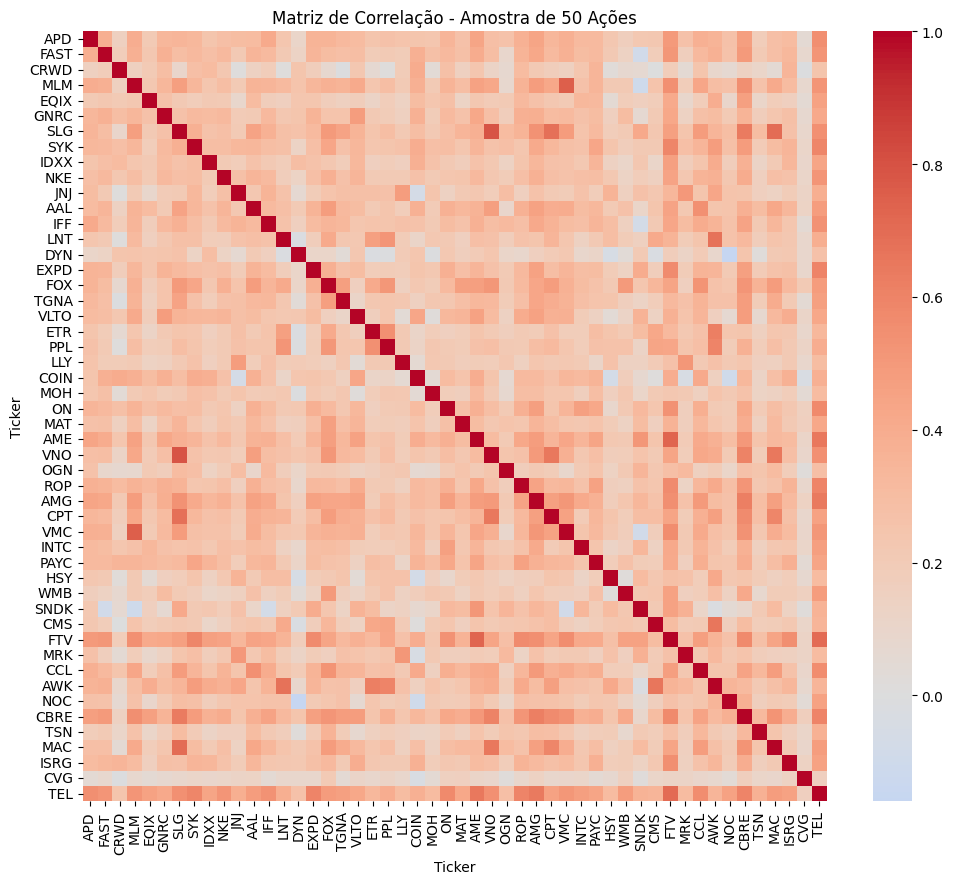

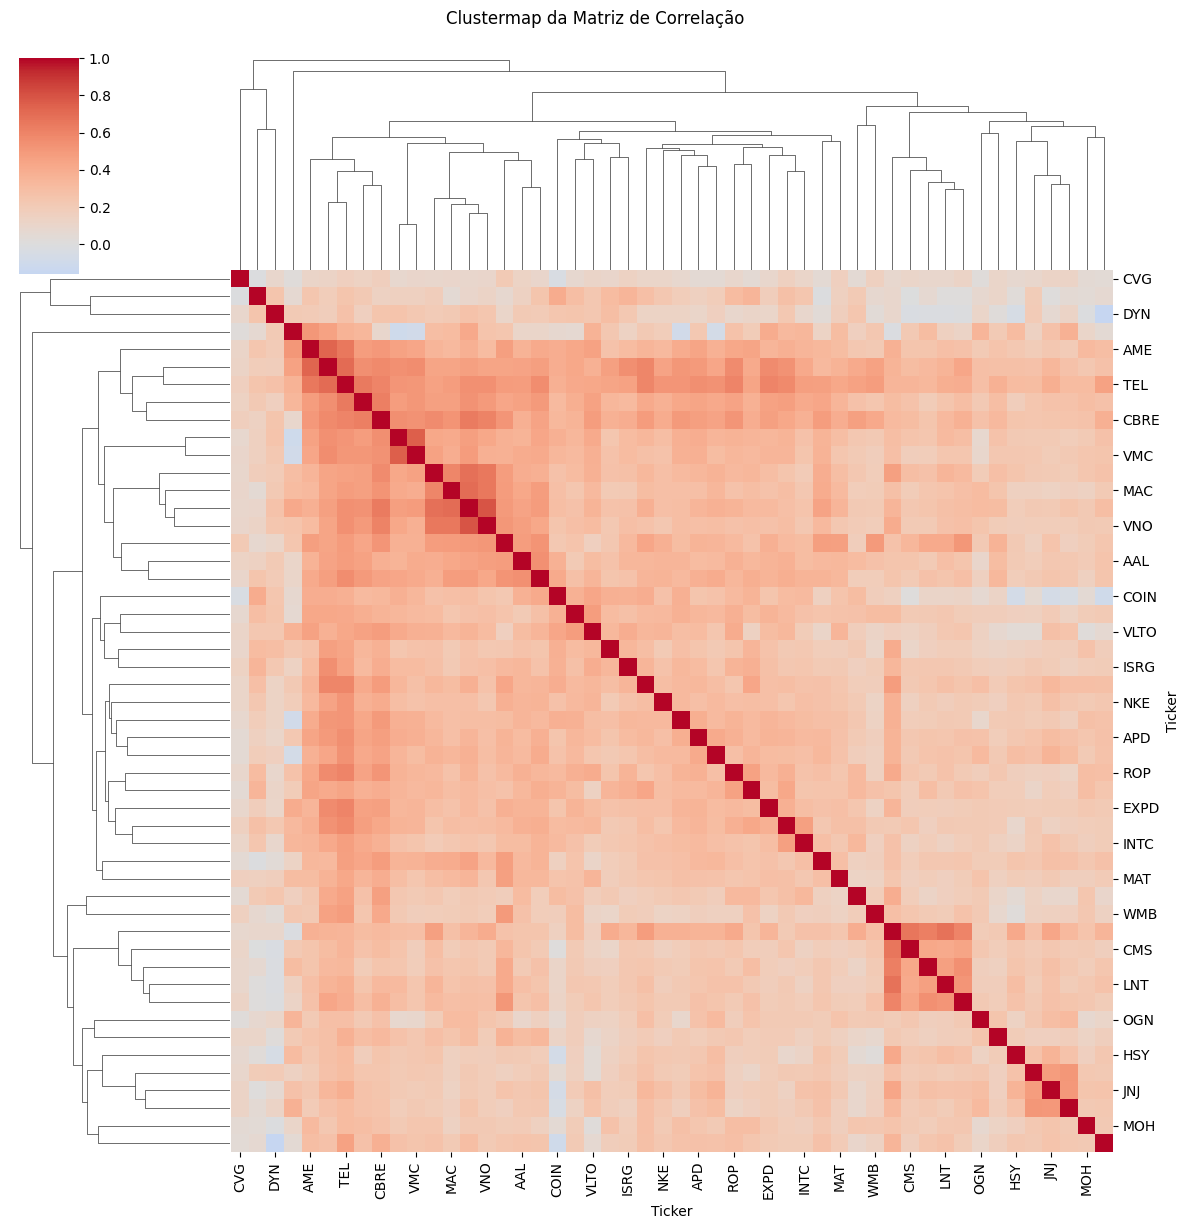

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_cluster_all = pd.read_csv("cluster_weekly.csv")

df_pivot = df_cluster_all.pivot(index="Date", columns="Ticker", values="Weekly_Return")

corr_matrix = df_pivot.corr()
corr_matrix.to_csv("matriz_correlacao.csv")

print("Matriz de correlação completa criada. Dimensões:", corr_matrix.shape)
print(corr_matrix.describe()) 

sampled_tickers = corr_matrix.sample(n=50, axis=1).columns

subset_corr_matrix = corr_matrix.loc[sampled_tickers, sampled_tickers]

plt.figure(figsize=(12,10))
sns.heatmap(subset_corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação - Amostra de 50 Ações")
plt.show()
sns.clustermap(subset_corr_matrix, cmap="coolwarm", center=0, figsize=(12, 12))
plt.suptitle("Clustermap da Matriz de Correlação", y=1.02)
plt.show()

In [7]:
import nasdaqdatalink as ndl
import pandas as pd
import time

ndl.ApiConfig.api_key = "cn_riEpJs1j5tBynK4bq"

# Ler lista de tickers válidos
df_tickers = pd.read_csv("valid_tickers.csv")
tickers = df_tickers["Ticker"].tolist()

# Apenas para um ticker de teste, para ver todas as colunas
ticker_test = tickers[0]

try:
    df = ndl.get_table(
        'SHARADAR/SF1',
        ticker=ticker_test,
        paginate=True
    )
    print(f"✅ Colunas disponíveis para {ticker_test}:")
    for col in df.columns:
        print(col)
except Exception as e:
    print(f"❌ Erro ao coletar {ticker_test}: {e}")

✅ Colunas disponíveis para A:
ticker
dimension
calendardate
datekey
reportperiod
fiscalperiod
lastupdated
accoci
assets
assetsavg
assetsc
assetsnc
assetturnover
bvps
capex
cashneq
cashnequsd
cor
consolinc
currentratio
de
debt
debtc
debtnc
debtusd
deferredrev
depamor
deposits
divyield
dps
ebit
ebitda
ebitdamargin
ebitdausd
ebitusd
ebt
eps
epsdil
epsusd
equity
equityavg
equityusd
ev
evebit
evebitda
fcf
fcfps
fxusd
gp
grossmargin
intangibles
intexp
invcap
invcapavg
inventory
investments
investmentsc
investmentsnc
liabilities
liabilitiesc
liabilitiesnc
marketcap
ncf
ncfbus
ncfcommon
ncfdebt
ncfdiv
ncff
ncfi
ncfinv
ncfo
ncfx
netinc
netinccmn
netinccmnusd
netincdis
netincnci
netmargin
opex
opinc
payables
payoutratio
pb
pe
pe1
ppnenet
prefdivis
price
ps
ps1
receivables
retearn
revenue
revenueusd
rnd
roa
roe
roic
ros
sbcomp
sgna
sharefactor
sharesbas
shareswa
shareswadil
sps
tangibles
taxassets
taxexp
taxliabilities
tbvps
workingcapital


In [8]:
import nasdaqdatalink as ndl
import pandas as pd
import time

# Configure sua API key
ndl.ApiConfig.api_key = "cn_riEpJs1j5tBynK4bq"

# Ler lista de tickers válidos
df_tickers = pd.read_csv("sp500_historical_list.csv")
tickers = df_tickers["Ticker"].tolist()

# DataFrame final
df_finance = pd.DataFrame()

# Intervalo de datas
start_date = "1900-01-01"
end_date = "2025-01-01"

# Colunas que queremos manter
columns_to_keep = [
    "ticker", "dimension", "calendardate", "revenue", "gp", "ebit", "ebitda", "ebitdamargin",
    "netinc", "netinccmn", "eps", "epsdil", "assets", "assetsavg", "equity", "equityavg",
    "liabilities", "liabilitiesc", "liabilitiesnc", "fcf", "fcfps", "capex", "de", "debt",
    "debtusd", "workingcapital", "tangibles", "pb", "pe", "ps", "marketcap", "dps",
    "divyield", "payoutratio", "roa", "roe", "roic", "sharesbas", "shareswa", "shareswadil"
]

# Limite de chamadas por minuto
CALLS_PER_MINUTE = 10
calls_count = 0
start_time = time.time()

def get_financials_safe(ticker):
    global calls_count, start_time
    try:
        # Respeitar limite de 10 chamadas por minuto
        if calls_count >= CALLS_PER_MINUTE:
            elapsed = time.time() - start_time
            if elapsed < 60:
                wait = 60 - elapsed
                print(f"⏳ Esperando {wait:.1f}s para não exceder limite...")
                time.sleep(wait)
            calls_count = 0
            start_time = time.time()

        df = ndl.get_table(
            'SHARADAR/SF1',
            ticker=ticker,
            calendarDate={'gte': start_date, 'lte': end_date},
            paginate=True
        )
        df = df[columns_to_keep]
        calls_count += 1
        return df

    except Exception as e:
        print(f"❌ Erro ao coletar {ticker}: {e}")
        return pd.DataFrame()

# Loop para todos os tickers
for i, ticker in enumerate(tickers):
    df_temp = get_financials_safe(ticker)
    if not df_temp.empty:
        df_finance = pd.concat([df_finance, df_temp], ignore_index=True)
        print(f"✅ {ticker} coletado ({i+1}/{len(tickers)})")
    else:
        print(f"⚠️ Nenhum dado para {ticker}")
    # Delay extra para segurança (pode reduzir se quiser)
    time.sleep(1)

# Salvar CSV final
df_finance.to_csv("finance_data_regression.csv", index=False)
print("✅ Todos os dados financeiros salvos!")

⚠️ Nenhum dado para A
⚠️ Nenhum dado para AA
⚠️ Nenhum dado para AAL
⚠️ Nenhum dado para AAP
✅ AAPL coletado (5/853)
⚠️ Nenhum dado para ABBV
⚠️ Nenhum dado para ABK
⚠️ Nenhum dado para ABMD
⚠️ Nenhum dado para ABNB
⚠️ Nenhum dado para ABS
⏳ Esperando 36.3s para não exceder limite...
⚠️ Nenhum dado para ABT
⚠️ Nenhum dado para ACAS
⚠️ Nenhum dado para ACE
⚠️ Nenhum dado para ACGL
⚠️ Nenhum dado para ACN
⚠️ Nenhum dado para ACT
⚠️ Nenhum dado para ADBE
⚠️ Nenhum dado para ADCT
⚠️ Nenhum dado para ADI
⚠️ Nenhum dado para ADM
⏳ Esperando 36.7s para não exceder limite...
⚠️ Nenhum dado para ADP
⚠️ Nenhum dado para ADS
⚠️ Nenhum dado para ADSK
⚠️ Nenhum dado para ADT
⚠️ Nenhum dado para AEE
⚠️ Nenhum dado para AEP
⚠️ Nenhum dado para AES
⚠️ Nenhum dado para AET
⚠️ Nenhum dado para AFL
⚠️ Nenhum dado para AGN
⏳ Esperando 33.4s para não exceder limite...
⚠️ Nenhum dado para AIG
⚠️ Nenhum dado para AIV
⚠️ Nenhum dado para AIZ
⚠️ Nenhum dado para AJG
⚠️ Nenhum dado para AKAM
⚠️ Nenhum dado para

In [7]:
import nasdaqdatalink as ndl
import pandas as pd
import time

ndl.ApiConfig.api_key = "cn_riEpJs1j5tBynK4bq"

# Ler lista de tickers válidos
df_tickers = pd.read_csv("valid_tickers.csv")
tickers = df_tickers["Ticker"].tolist()

# Apenas para um ticker de teste, para ver todas as colunas
ticker_test = tickers[0]

try:
    df = ndl.get_table(
        'SHARADAR/SF1',
        ticker=ticker_test,
        paginate=True
    )
    print(f"✅ Colunas disponíveis para {ticker_test}:")
    for col in df.columns:
        print(col)
except Exception as e:
    print(f"❌ Erro ao coletar {ticker_test}: {e}")

✅ Colunas disponíveis para A:
ticker
dimension
calendardate
datekey
reportperiod
fiscalperiod
lastupdated
accoci
assets
assetsavg
assetsc
assetsnc
assetturnover
bvps
capex
cashneq
cashnequsd
cor
consolinc
currentratio
de
debt
debtc
debtnc
debtusd
deferredrev
depamor
deposits
divyield
dps
ebit
ebitda
ebitdamargin
ebitdausd
ebitusd
ebt
eps
epsdil
epsusd
equity
equityavg
equityusd
ev
evebit
evebitda
fcf
fcfps
fxusd
gp
grossmargin
intangibles
intexp
invcap
invcapavg
inventory
investments
investmentsc
investmentsnc
liabilities
liabilitiesc
liabilitiesnc
marketcap
ncf
ncfbus
ncfcommon
ncfdebt
ncfdiv
ncff
ncfi
ncfinv
ncfo
ncfx
netinc
netinccmn
netinccmnusd
netincdis
netincnci
netmargin
opex
opinc
payables
payoutratio
pb
pe
pe1
ppnenet
prefdivis
price
ps
ps1
receivables
retearn
revenue
revenueusd
rnd
roa
roe
roic
ros
sbcomp
sgna
sharefactor
sharesbas
shareswa
shareswadil
sps
tangibles
taxassets
taxexp
taxliabilities
tbvps
workingcapital


In [8]:
import nasdaqdatalink as ndl
import pandas as pd
import time

# Configure sua API key
ndl.ApiConfig.api_key = "cn_riEpJs1j5tBynK4bq"

# Ler lista de tickers válidos
df_tickers = pd.read_csv("sp500_historical_list.csv")
tickers = df_tickers["Ticker"].tolist()

# DataFrame final
df_finance = pd.DataFrame()

# Intervalo de datas
start_date = "1900-01-01"
end_date = "2025-01-01"

# Colunas que queremos manter
columns_to_keep = [
    "ticker", "dimension", "calendardate", "revenue", "gp", "ebit", "ebitda", "ebitdamargin",
    "netinc", "netinccmn", "eps", "epsdil", "assets", "assetsavg", "equity", "equityavg",
    "liabilities", "liabilitiesc", "liabilitiesnc", "fcf", "fcfps", "capex", "de", "debt",
    "debtusd", "workingcapital", "tangibles", "pb", "pe", "ps", "marketcap", "dps",
    "divyield", "payoutratio", "roa", "roe", "roic", "sharesbas", "shareswa", "shareswadil"
]

# Limite de chamadas por minuto
CALLS_PER_MINUTE = 10
calls_count = 0
start_time = time.time()

def get_financials_safe(ticker):
    global calls_count, start_time
    try:
        # Respeitar limite de 10 chamadas por minuto
        if calls_count >= CALLS_PER_MINUTE:
            elapsed = time.time() - start_time
            if elapsed < 60:
                wait = 60 - elapsed
                print(f"⏳ Esperando {wait:.1f}s para não exceder limite...")
                time.sleep(wait)
            calls_count = 0
            start_time = time.time()

        df = ndl.get_table(
            'SHARADAR/SF1',
            ticker=ticker,
            calendarDate={'gte': start_date, 'lte': end_date},
            paginate=True
        )
        df = df[columns_to_keep]
        calls_count += 1
        return df

    except Exception as e:
        print(f"❌ Erro ao coletar {ticker}: {e}")
        return pd.DataFrame()

# Loop para todos os tickers
for i, ticker in enumerate(tickers):
    df_temp = get_financials_safe(ticker)
    if not df_temp.empty:
        df_finance = pd.concat([df_finance, df_temp], ignore_index=True)
        print(f"✅ {ticker} coletado ({i+1}/{len(tickers)})")
    else:
        print(f"⚠️ Nenhum dado para {ticker}")
    # Delay extra para segurança (pode reduzir se quiser)
    time.sleep(1)

# Salvar CSV final
df_finance.to_csv("finance_data_regression.csv", index=False)
print("✅ Todos os dados financeiros salvos!")

⚠️ Nenhum dado para A
⚠️ Nenhum dado para AA
⚠️ Nenhum dado para AAL
⚠️ Nenhum dado para AAP
✅ AAPL coletado (5/853)
⚠️ Nenhum dado para ABBV
⚠️ Nenhum dado para ABK
⚠️ Nenhum dado para ABMD
⚠️ Nenhum dado para ABNB
⚠️ Nenhum dado para ABS
⏳ Esperando 36.3s para não exceder limite...
⚠️ Nenhum dado para ABT
⚠️ Nenhum dado para ACAS
⚠️ Nenhum dado para ACE
⚠️ Nenhum dado para ACGL
⚠️ Nenhum dado para ACN
⚠️ Nenhum dado para ACT
⚠️ Nenhum dado para ADBE
⚠️ Nenhum dado para ADCT
⚠️ Nenhum dado para ADI
⚠️ Nenhum dado para ADM
⏳ Esperando 36.7s para não exceder limite...
⚠️ Nenhum dado para ADP
⚠️ Nenhum dado para ADS
⚠️ Nenhum dado para ADSK
⚠️ Nenhum dado para ADT
⚠️ Nenhum dado para AEE
⚠️ Nenhum dado para AEP
⚠️ Nenhum dado para AES
⚠️ Nenhum dado para AET
⚠️ Nenhum dado para AFL
⚠️ Nenhum dado para AGN
⏳ Esperando 33.4s para não exceder limite...
⚠️ Nenhum dado para AIG
⚠️ Nenhum dado para AIV
⚠️ Nenhum dado para AIZ
⚠️ Nenhum dado para AJG
⚠️ Nenhum dado para AKAM
⚠️ Nenhum dado para

Obter Dados Macroeconomicos, indíces e dados de crédito pelo FRED

In [ ]:
import pandas as pd
from fredapi import Fred

fred = Fred(api_key='8f01c5703f25d5ea61bb466337b2a5c7')

series = {
    # Macroeconômicos
    "taxa_juros": "FEDFUNDS",
    "inflacao_cpi": "CPIAUCSL",
    "pib_real": "GDPC1",  # trimestral
    "massa_monetaria": "M2SL",
    "desemprego": "UNRATE",
    "dolar_index": "DTWEXBGS",
    "juros_t10y": "GS10",
    "ouro": "PCU2122212122210",

    # Índices de mercado
    "sp500": "SP500",
    "dow_jones": "DJIA",
    "nasdaq": "NASDAQCOM",

    # Crédito
    "corporate_baa": "BAA",
    "credito_cartao": "TERMCBCCALLNS",
    "mortgage_30y": "MORTGAGE30US"
}

df = pd.DataFrame()

for nome, codigo in series.items():
    try:
        serie = fred.get_series(codigo)
        df[nome] = serie
    except Exception as e:
        print(f"Erro ao baixar {nome}: {e}")

# Ajustar frequência mensal (algumas séries podem ser trimestrais ou diárias)
df = df.resample("M").last()  # pega o último valor de cada mês

# Preencher PIB trimestral com forward-fill
df["pib_real"] = df["pib_real"].ffill()

# Salvar CSV
df.to_csv("dados_macro_fred.csv")
print("✅ CSV gerado com sucesso!")

In [2]:
import requests
import pandas as pd
import time

# Identificação obrigatória (troque pelo seu email real!)
headers = {"User-Agent": "joaobussi@usp.br"}

# Baixar lista oficial de tickers/CIKs
url_tickers = "https://www.sec.gov/files/company_tickers.json"
tickers_json = requests.get(url_tickers, headers=headers).json()

# Criar mapa Ticker -> CIK
ticker_to_cik = {entry["ticker"]: str(entry["cik_str"]).zfill(10) for entry in tickers_json.values()}

# Sua lista de tickers
df_tickers = pd.read_csv("sp500_historical_list.csv")
tickers = df_tickers["Ticker"].tolist()

all_data = []

def get_company_facts(cik, ticker, retries=3, delay=2):
    """
    Obtém métricas financeiras de uma empresa pelo CIK no SEC EDGAR.
    Inclui retry automático e delay entre tentativas.
    
    Retorna: lista de dicionários com métricas ou None se não for possível.
    """
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik.zfill(10)}.json"
    
    for attempt in range(retries):
        try:
            r = requests.get(url, headers=headers, timeout=10)
            if r.status_code == 200:
                data = r.json()
                results = []

                metrics = [
                    "Assets", "Liabilities", "StockholdersEquity",
                    "Revenues", "NetIncomeLoss", "EarningsPerShareDiluted",
                    "NetCashProvidedByUsedInOperatingActivities",
                    "PaymentsOfDividendsCommonStock",
                    "CommonStockSharesOutstanding",
                    # Métricas adicionais
                    "AssetsCurrent", "LiabilitiesCurrent",
                    "CapitalExpenditures", "GrossProfit",
                    "OperatingIncomeLoss", "InterestExpense"
                ]

                for m in metrics:
                    metric_data = data["facts"].get("us-gaap", {}).get(m, {})
                    units_dict = metric_data.get("units", {})
                    
                    # Prioriza USD, depois shares
                    if "USD" in units_dict:
                        vals = units_dict["USD"]
                    elif "shares" in units_dict:
                        vals = units_dict["shares"]
                    else:
                        vals = []

                    for v in vals:
                        results.append({
                            "ticker": ticker,
                            "metric": m,
                            "val": v.get("val"),
                            "end": v.get("end"),
                            "fy": v.get("fy"),
                            "fp": v.get("fp"),
                            "form": v.get("form"),
                            "filed": v.get("filed")
                        })
                return results
            
            else:
                print(f"❌ Erro {r.status_code} para {ticker}")
        
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Tentativa {attempt+1} falhou para {ticker}: {e}")
        
        time.sleep(delay)  # espera antes de tentar novamente
    
    print(f"❌ Não foi possível coletar dados para {ticker} após {retries} tentativas")
    return []

for i, ticker in enumerate(tickers):
    cik = ticker_to_cik.get(ticker)
    if not cik:
        print(f"⚠️ Ticker {ticker} não encontrado")
        continue
    
    data = get_company_facts(cik, ticker)
    if data:
        all_data.extend(data)
        print(f"✅ {ticker} coletado ({i+1}/{len(tickers)})")
    else:
        print(f"⚠️ Nenhum dado para {ticker}")
    
    # Evitar bloqueio da SEC
    time.sleep(0.5)

# Salvar em CSV
df = pd.DataFrame(all_data)
df.to_csv("sec_financials.csv", index=False)
print("📁 Dados salvos em sec_financials.csv")

✅ A coletado (1/853)
✅ AA coletado (2/853)
✅ AAL coletado (3/853)
✅ AAP coletado (4/853)
✅ AAPL coletado (5/853)
✅ ABBV coletado (6/853)
⚠️ Ticker ABK não encontrado
⚠️ Ticker ABMD não encontrado
✅ ABNB coletado (9/853)
⚠️ Ticker ABS não encontrado
✅ ABT coletado (11/853)
⚠️ Ticker ACAS não encontrado
⚠️ Ticker ACE não encontrado
✅ ACGL coletado (14/853)
✅ ACN coletado (15/853)
✅ ACT coletado (16/853)
✅ ADBE coletado (17/853)
✅ ADCT coletado (18/853)
✅ ADI coletado (19/853)
✅ ADM coletado (20/853)
✅ ADP coletado (21/853)
⚠️ Ticker ADS não encontrado
✅ ADSK coletado (23/853)
✅ ADT coletado (24/853)
✅ AEE coletado (25/853)
✅ AEP coletado (26/853)
✅ AES coletado (27/853)
⚠️ Ticker AET não encontrado
✅ AFL coletado (29/853)
⚠️ Ticker AGN não encontrado
✅ AIG coletado (31/853)
✅ AIV coletado (32/853)
✅ AIZ coletado (33/853)
✅ AJG coletado (34/853)
✅ AKAM coletado (35/853)
⚠️ Ticker AKS não encontrado
✅ ALB coletado (37/853)
✅ ALGN coletado (38/853)
✅ ALK coletado (39/853)
✅ ALL coletado (40

In [4]:
import pandas as pd
import yfinance as yf

# ------------------------------
# 1. Carregar dados brutos
# ------------------------------
df = pd.read_csv("sec_financials.csv")
df["end"] = pd.to_datetime(df["end"], errors="coerce")

# ------------------------------
# 2. Pivotar métricas -> colunas
# ------------------------------
df_pivot = df.pivot_table(
    index=["ticker", "end", "fy", "fp", "form", "filed"],
    columns="metric",
    values="val",
    aggfunc="first"
).reset_index()

# ------------------------------
# 3. Separar trimestral e anual
# ------------------------------
df_quarterly = df_pivot[df_pivot["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()
df_annual = df_pivot[df_pivot["fp"].isin(["FY"])].copy()

# ------------------------------
# 4. Adicionar preços históricos
# ------------------------------
def add_prices(df_fin):
    tickers = df_fin["ticker"].unique()
    all_with_prices = []

    for t in tickers:
        df_sub = df_fin[df_fin["ticker"] == t].copy()
        if df_sub.empty:
            continue

        start = df_sub["end"].min() - pd.Timedelta(days=30)
        end = df_sub["end"].max() + pd.Timedelta(days=30)

        try:
            hist = yf.download(
                t,
                start=start.strftime("%Y-%m-%d"),
                end=end.strftime("%Y-%m-%d"),
                progress=False,
                auto_adjust=False  # evita mudanças futuras no padrão
            )

            # Garante coluna única
            if isinstance(hist.columns, pd.MultiIndex):
                hist.columns = hist.columns.get_level_values(0)

            hist = hist[["Close"]].reset_index()
            hist.rename(columns={"Date": "end", "Close": "ClosePrice"}, inplace=True)

            # Merge aproximado para alinhar datas
            merged = pd.merge_asof(
                df_sub.sort_values("end"),
                hist.sort_values("end"),
                on="end",
                direction="backward"
            )
            all_with_prices.append(merged)
            print(f"💰 Preços adicionados para {t}")
        except Exception as e:
            print(f"⚠️ Erro ao buscar preços para {t}: {e}")

    if all_with_prices:
        return pd.concat(all_with_prices, ignore_index=True)
    else:
        return df_fin

df_quarterly = add_prices(df_quarterly)
df_annual = add_prices(df_annual)

# ------------------------------
# 5. Salvar resultados
# ------------------------------
df_quarterly.to_csv("sec_quarterly.csv", index=False)
df_annual.to_csv("sec_annual.csv", index=False)

print("📁 Dados organizados e salvos: sec_quarterly.csv e sec_annual.csv")

💰 Preços adicionados para A
💰 Preços adicionados para AA
💰 Preços adicionados para AAL
💰 Preços adicionados para AAP
💰 Preços adicionados para AAPL
💰 Preços adicionados para ABBV
💰 Preços adicionados para ABNB
💰 Preços adicionados para ABT
💰 Preços adicionados para ACGL
💰 Preços adicionados para ACN
💰 Preços adicionados para ACT
💰 Preços adicionados para ADBE
💰 Preços adicionados para ADCT
💰 Preços adicionados para ADI
💰 Preços adicionados para ADM
💰 Preços adicionados para ADP
💰 Preços adicionados para ADSK
💰 Preços adicionados para ADT
💰 Preços adicionados para AEE
💰 Preços adicionados para AEP
💰 Preços adicionados para AES
💰 Preços adicionados para AFL
💰 Preços adicionados para AIG
💰 Preços adicionados para AIV
💰 Preços adicionados para AIZ
💰 Preços adicionados para AJG
💰 Preços adicionados para AKAM
💰 Preços adicionados para ALB
💰 Preços adicionados para ALGN
💰 Preços adicionados para ALK
💰 Preços adicionados para ALL
💰 Preços adicionados para ALLE
💰 Preços adicionados para AMAT
💰 


1 Failed download:
['EMN']: Timeout('Failed to perform, curl: (28) Connection timed out after 10013 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


💰 Preços adicionados para EMN
💰 Preços adicionados para EMR
💰 Preços adicionados para ENPH
💰 Preços adicionados para EOG
💰 Preços adicionados para EP
💰 Preços adicionados para EPAM
💰 Preços adicionados para EQIX
💰 Preços adicionados para EQR
💰 Preços adicionados para EQT
💰 Preços adicionados para ERIE
💰 Preços adicionados para ES
💰 Preços adicionados para ESS
💰 Preços adicionados para ETN
💰 Preços adicionados para ETR
💰 Preços adicionados para ETSY
💰 Preços adicionados para EVRG
💰 Preços adicionados para EW
💰 Preços adicionados para EXC
💰 Preços adicionados para EXE
💰 Preços adicionados para EXPD
💰 Preços adicionados para EXPE
💰 Preços adicionados para EXR
💰 Preços adicionados para F
💰 Preços adicionados para FANG
💰 Preços adicionados para FAST
💰 Preços adicionados para FCX
💰 Preços adicionados para FDS
💰 Preços adicionados para FDX
💰 Preços adicionados para FE
💰 Preços adicionados para FFIV
💰 Preços adicionados para FHN
💰 Preços adicionados para FI
💰 Preços adicionados para FICO
💰 Pre

In [ ]:
import pandas as pd

df = pd.read_csv("sec_annual.csv")

# Criar coluna de ano
df["year"] = pd.to_datetime(df["end"], errors="coerce").dt.year


def clean_table(df_in):
    """
    Limpa e organiza a tabela:
    - Mantém somente ticker, year, metric, val
    - Remove duplicatas mantendo último 'filed'
    - Faz pivot (cada métrica vira coluna)
    """
    # Ordenar para manter o último filed
    df_sorted = df_in.sort_values(["ticker", "year", "filed"])
    
    # Dropar duplicatas
    df_dedup = df_sorted.drop_duplicates(
        subset=["ticker", "year"], keep="last"
    )
    df_clean = df_dedup.drop(columns=["end", "fy", "fp", "form", "filed"])
    
    cols = df_clean.columns.tolist()
    cols.remove("ticker")
    cols.remove("year")
    ordered_cols = ["ticker", "year"] + cols
    df_clean = df_clean[ordered_cols]
    
    return df_clean

# Aplicar para anuais e trimestrais
df_annual_clean = clean_table(df)

# Salvar tabelas finais
df_annual_clean.to_csv("sec_annual.csv", index=False)

print("✅ Tabelas limpas salvas!")

KeyError: 'filed'

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import fcluster

# Ler a tabela anual limpa
df = pd.read_csv("sec_annual.csv")

# Converter todas as colunas financeiras para float
financial_cols = [
    "Assets", "AssetsCurrent", "CommonStockSharesOutstanding",
    "EarningsPerShareDiluted", "GrossProfit", "InterestExpense",
    "Liabilities", "LiabilitiesCurrent",
    "NetCashProvidedByUsedInOperatingActivities",
    "NetIncomeLoss", "OperatingIncomeLoss",
    "PaymentsOfDividendsCommonStock", "Revenues", "StockholdersEquity",
    "ClosePrice"
]

for col in financial_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Criar indicadores
df["NetMargin"] = df["NetIncomeLoss"] / df["Revenues"]
df["ROA"] = df["NetIncomeLoss"] / df["Assets"]
df["ROE"] = df["NetIncomeLoss"] / df["StockholdersEquity"]
df["DebtToEquity"] = df["Liabilities"] / df["StockholdersEquity"]
df["CurrentRatio"] = df["AssetsCurrent"] / df["LiabilitiesCurrent"]
df["InterestCoverage"] = df["OperatingIncomeLoss"] / df["InterestExpense"]
df["DividendYield"] = (df["PaymentsOfDividendsCommonStock"]/df["CommonStockSharesOutstanding"]) / df["ClosePrice"]
df["GrossMargin"] = df["GrossProfit"] / df["Revenues"]
df["MarketCap"] = df["ClosePrice"] * df["CommonStockSharesOutstanding"]
df["PE"] = df["ClosePrice"] / df["EarningsPerShareDiluted"]
df.loc[df["EarningsPerShareDiluted"] == 0, "PE"] = np.nan
df["CapEx"] = df["Assets"] - df["AssetsCurrent"]
df["FCF"] = df["NetCashProvidedByUsedInOperatingActivities"] - df["CapEx"]
df["FCF_Yield"] = df["FCF"] / df["MarketCap"]
df["OperatingMargin"] = df["OperatingIncomeLoss"] / df["Revenues"]
df["DividendPayout"] = df["PaymentsOfDividendsCommonStock"] / df["NetIncomeLoss"]
df.loc[df["NetIncomeLoss"] == 0, "DividendPayout"] = np.nan

# Valores incompletos já ficam NaN automaticamente
# Salvar tabela final
df.to_csv("sec_annual.csv", index=False)
print("✅ Indicadores calculados e tabela salva em sec_annual.csv")

✅ Indicadores calculados e tabela salva em sec_annual.csv


✅ Matriz de correlação carregada com sucesso.

Dimensões da matriz original: (634, 634)

Removendo 7 tickers com muitos valores nulos.
Dimensões da matriz após remoção: (627, 627)
✅ Matriz de correlação final está limpa e pronta para o clustering.


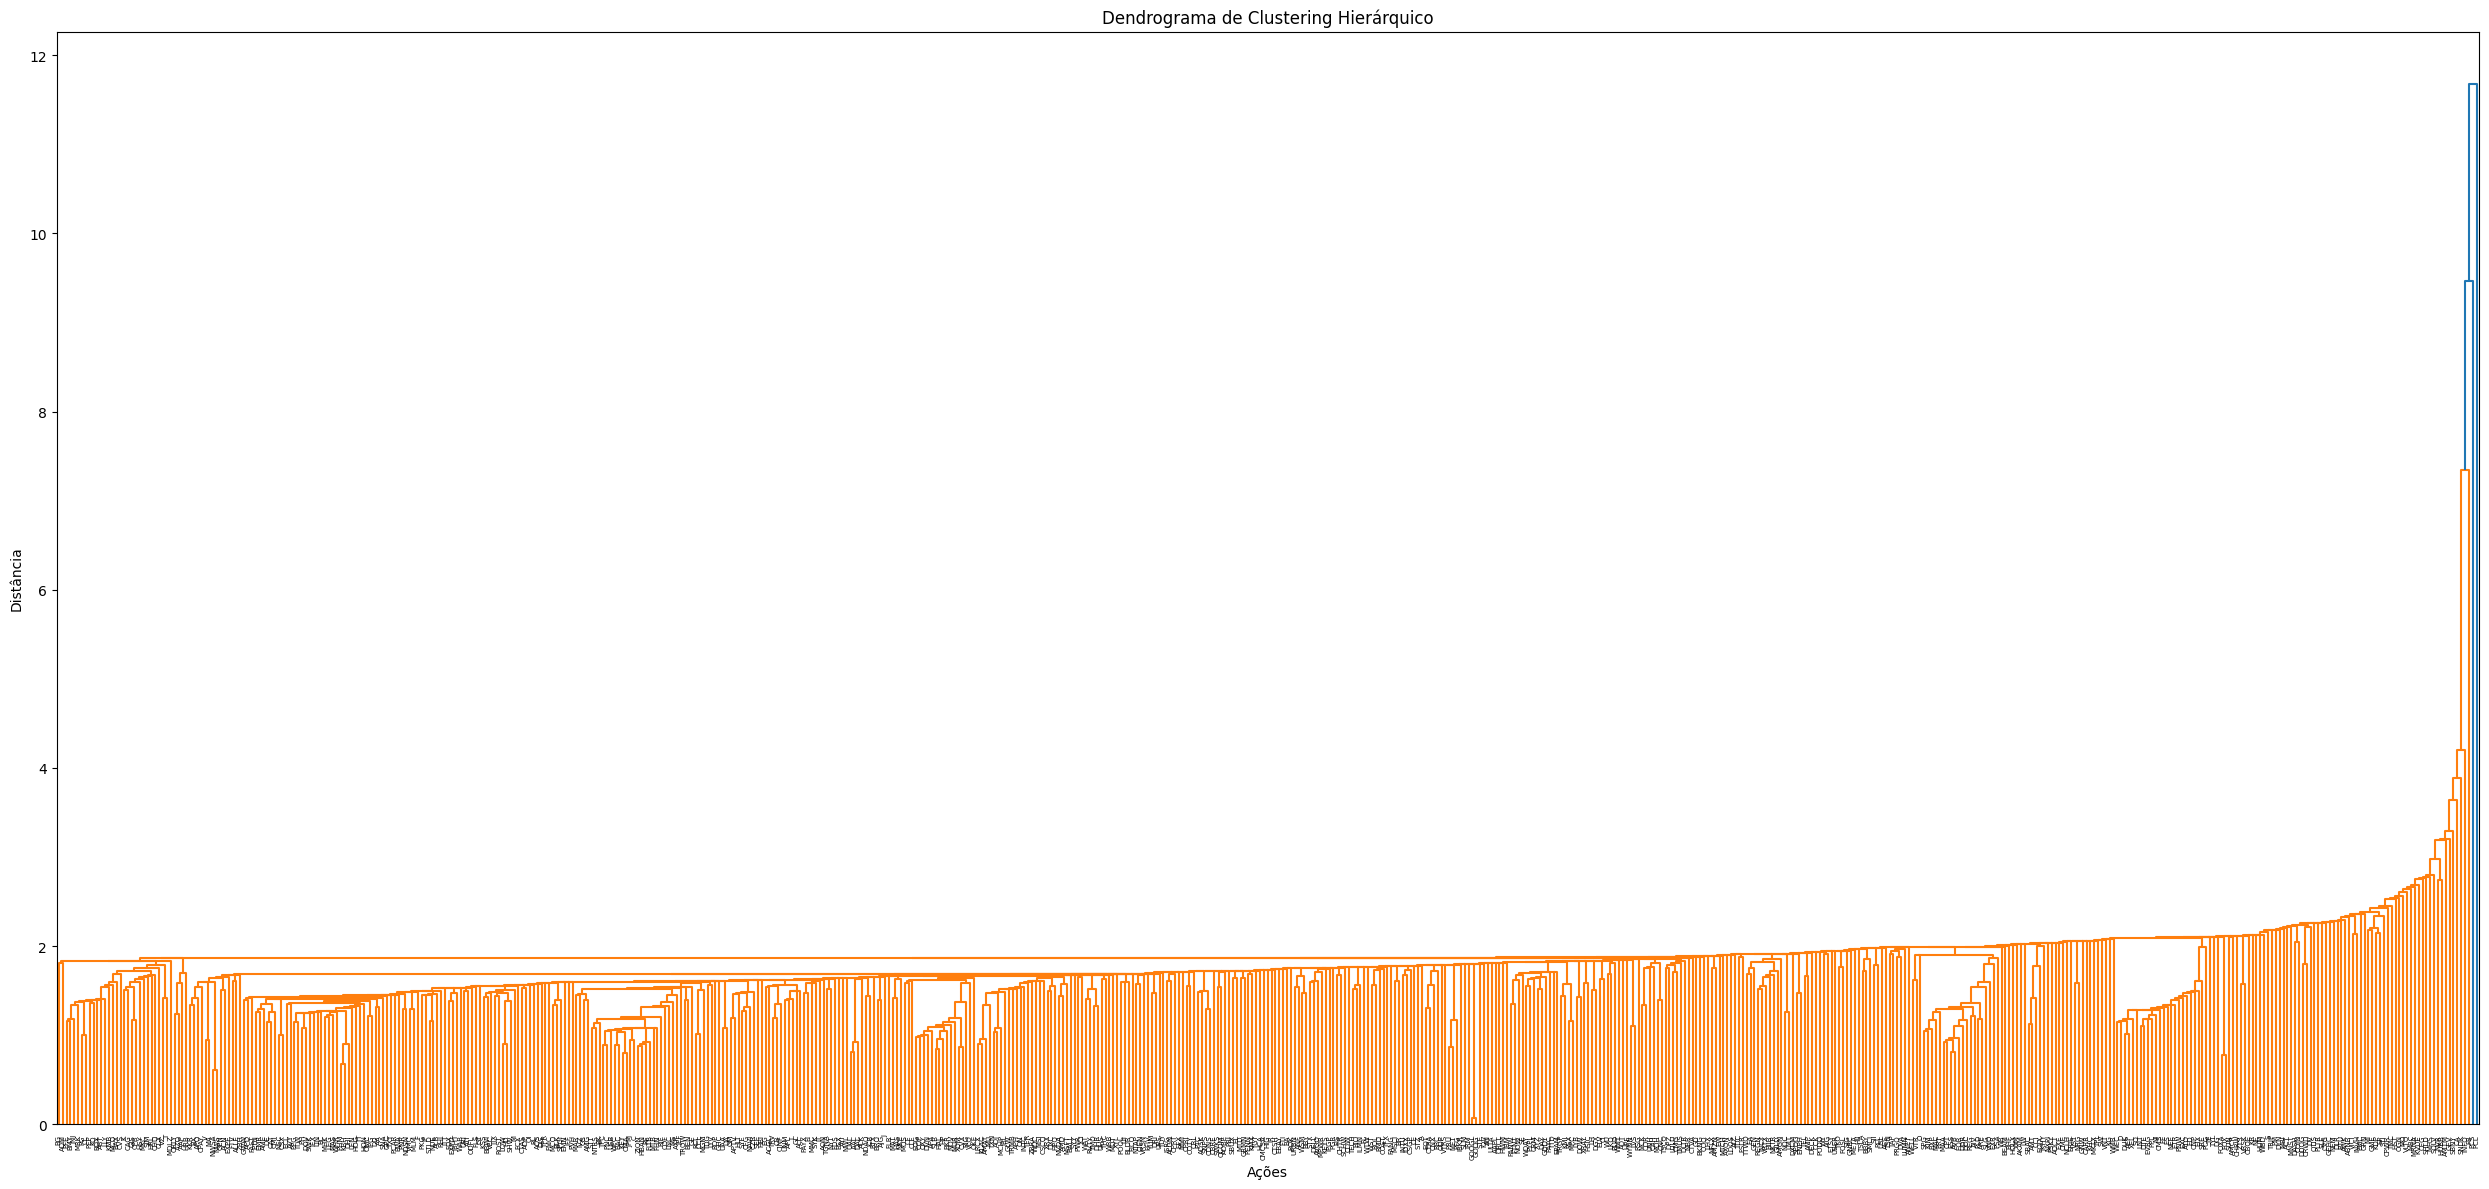

d:\Portavel\Python\Python3.13.7\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
d:\Portavel\Python\Python3.13.7\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1500x1500 with 0 Axes>

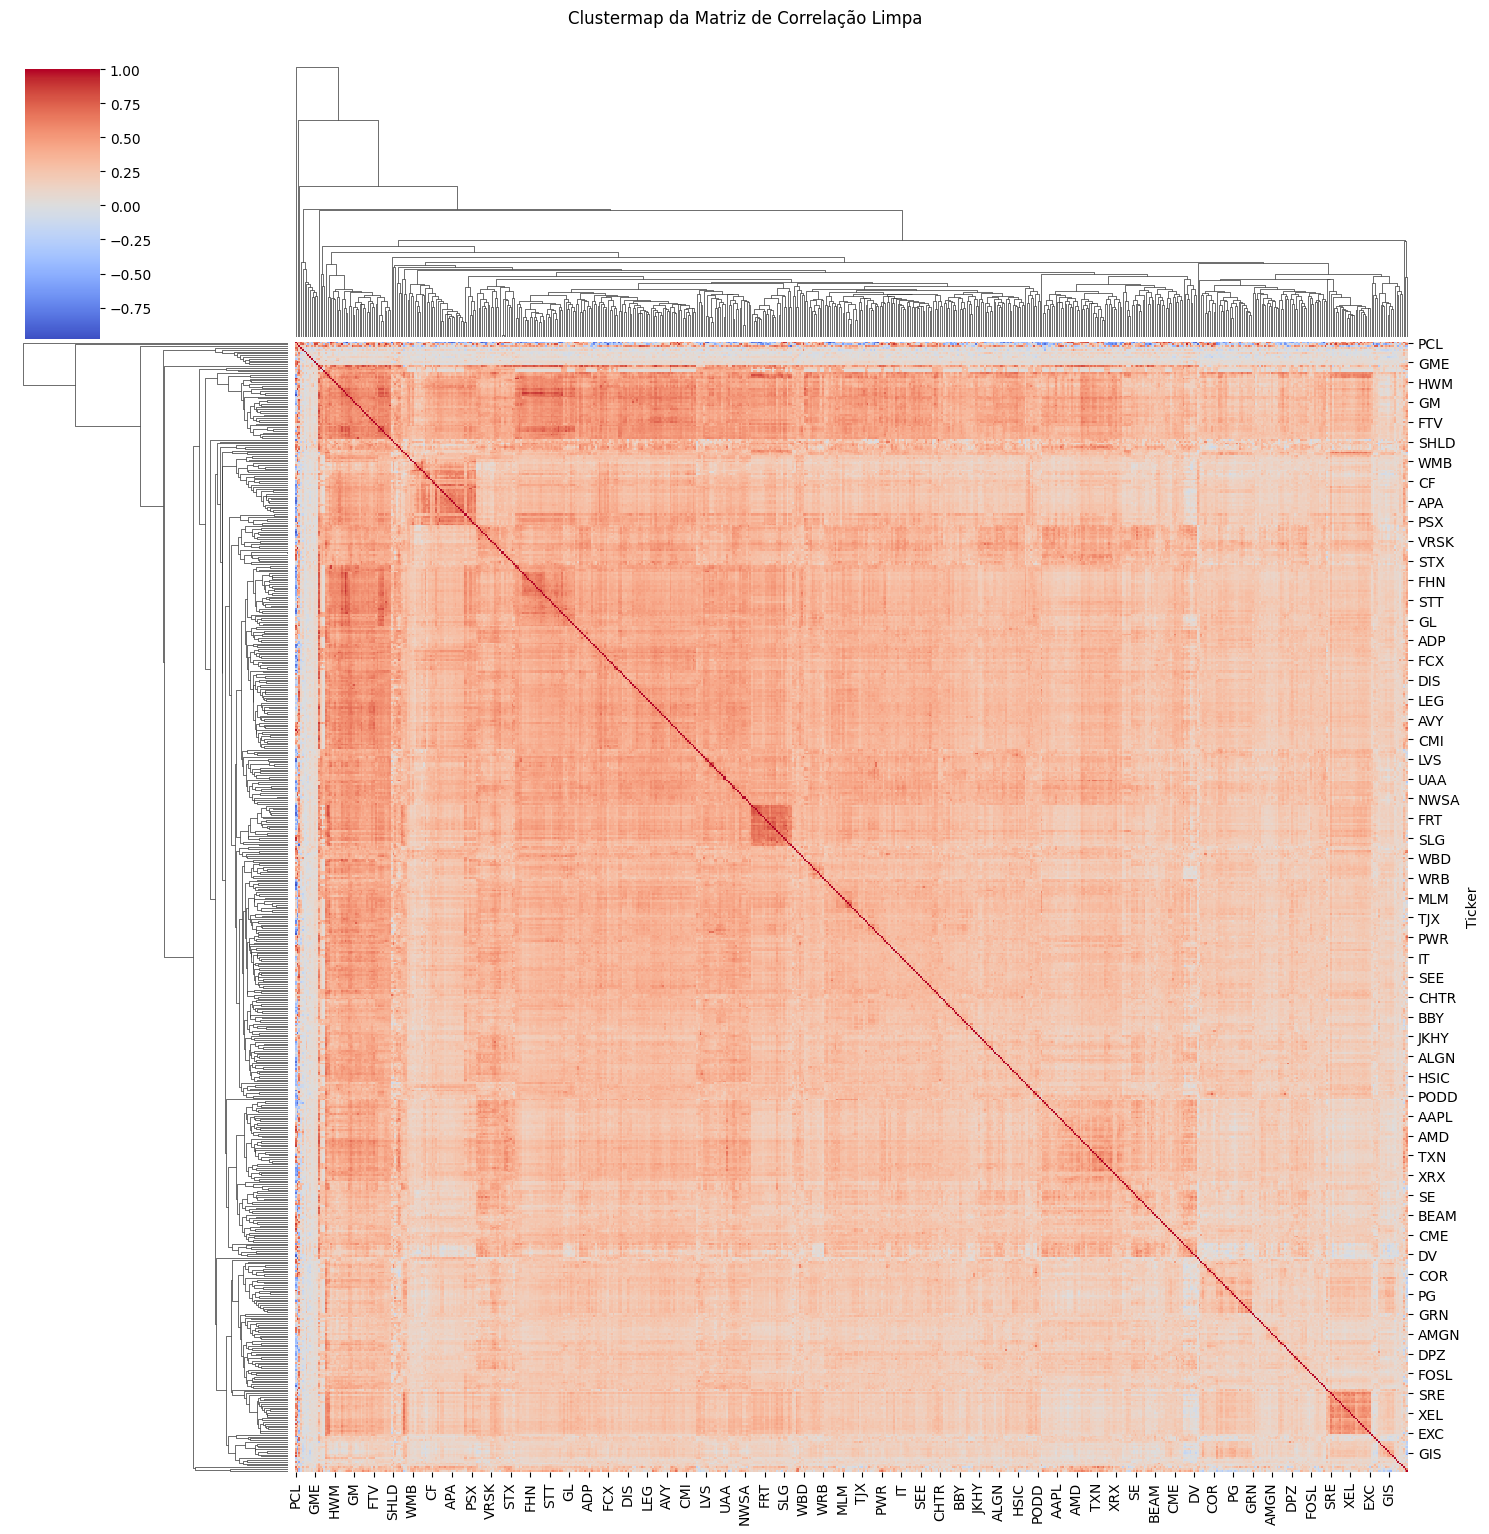

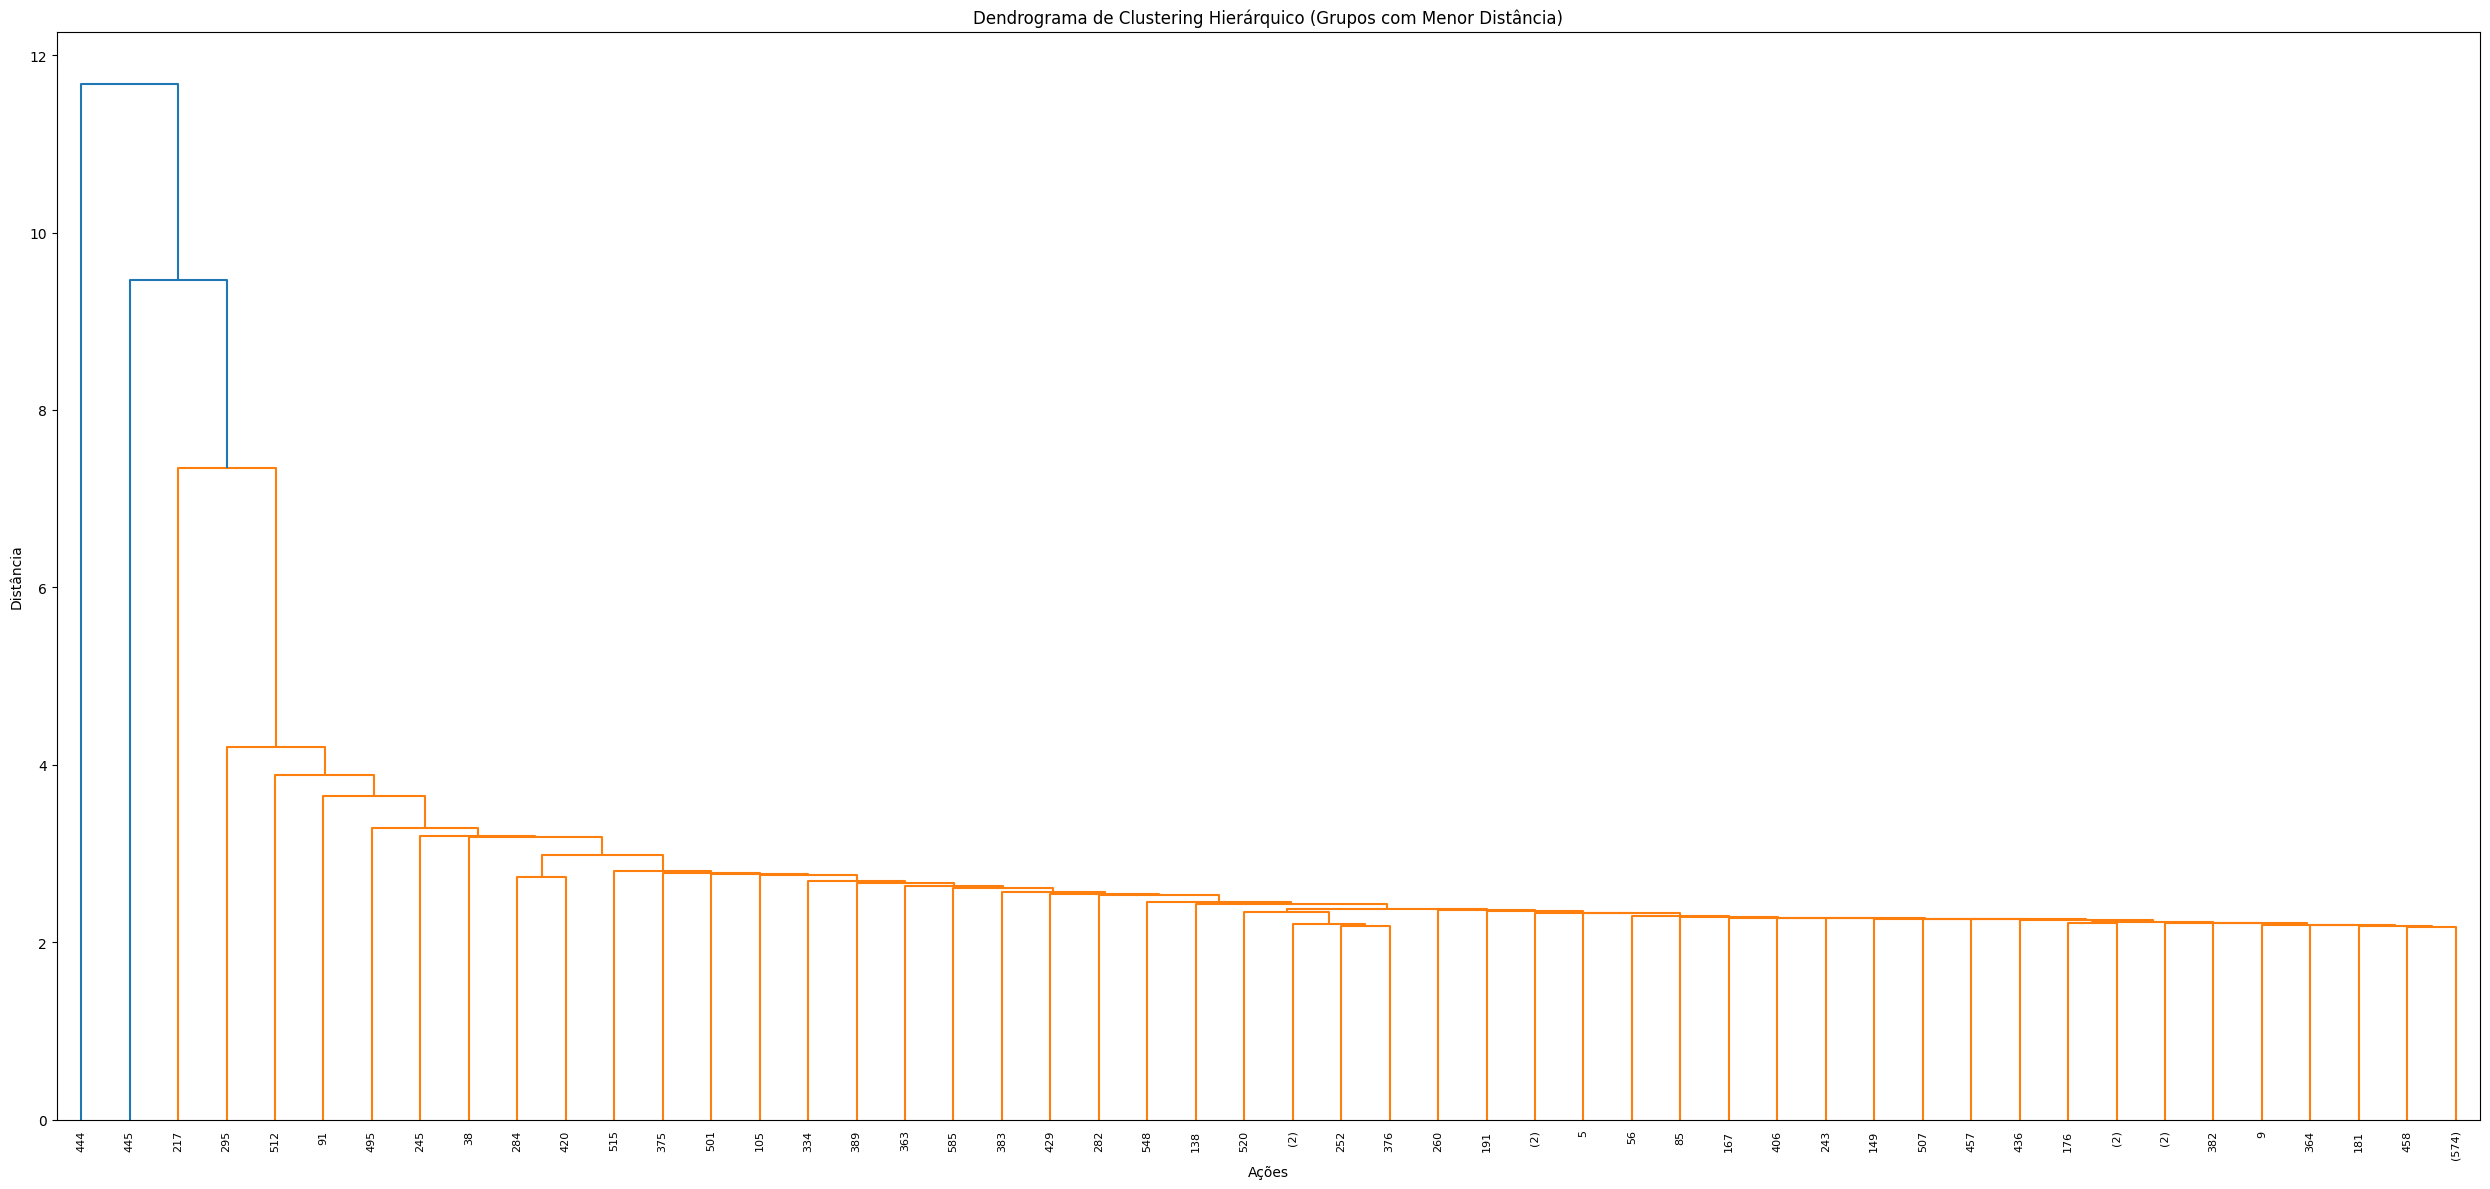

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# ----------------------------------------------------
# 1. Carregar a matriz de correlação
# ----------------------------------------------------
try:
    corr_matrix = pd.read_csv("matriz_correlacao.csv", index_col=0)
    print("✅ Matriz de correlação carregada com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo 'matriz_correlacao.csv' não foi encontrado.")
    exit()

# ----------------------------------------------------
# 2. Limpeza de Dados Inteligente
# ----------------------------------------------------
print("\nDimensões da matriz original:", corr_matrix.shape)

# Contar o número de valores nulos por coluna
nulos_por_coluna = corr_matrix.isnull().sum(axis=0)

# Encontrar o número de colunas com mais de 50% de valores nulos
limite_50_porcento = len(corr_matrix.index) * 0.5
colunas_a_remover = nulos_por_coluna[nulos_por_coluna > limite_50_porcento].index

# Remover as colunas e as linhas correspondentes
corr_matrix_cleaned = corr_matrix.drop(index=colunas_a_remover, columns=colunas_a_remover)

print(f"\nRemovendo {len(colunas_a_remover)} tickers com muitos valores nulos.")
print("Dimensões da matriz após remoção:", corr_matrix_cleaned.shape)

# Preencher os valores NaN restantes com a mediana da coluna
corr_matrix_final = corr_matrix_cleaned.fillna(corr_matrix_cleaned.median())

# Verificação final para garantir que não restam NaNs
if corr_matrix_final.isnull().any().any():
    print("⚠️ Aviso: Ainda existem valores NaN na matriz. Verifique o código.")
else:
    print("✅ Matriz de correlação final está limpa e pronta para o clustering.")

# ----------------------------------------------------
# 3. Realizar o Clustering Hierárquico
# ----------------------------------------------------
# Converte a matriz de correlação para uma matriz de distância
distance_matrix = 1 - corr_matrix_final

# Realiza o agrupamento com a matriz de distância
linked = linkage(distance_matrix, method='single')

# ----------------------------------------------------
# 4. Visualização do Dendrograma
# ----------------------------------------------------
plt.figure(figsize=(25, 12))
plt.title('Dendrograma de Clustering Hierárquico')
plt.xlabel('Ações')
plt.ylabel('Distância')

dendrogram(linked,
           orientation='top',
           labels=corr_matrix_final.columns,
           distance_sort='descending',
           show_leaf_counts=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 15))
sns.clustermap(corr_matrix_final, cmap="coolwarm", center=0, figsize=(15, 15))
plt.suptitle("Clustermap da Matriz de Correlação Limpa", y=1.02)
plt.show()

plt.figure(figsize=(25, 12))
plt.title('Dendrograma de Clustering Hierárquico (Grupos com Menor Distância)')
plt.xlabel('Ações')
plt.ylabel('Distância')

dendrogram(linked,
           truncate_mode='lastp',
           p=50,
           show_leaf_counts=True,
           distance_sort='ascending',
           leaf_rotation=90,
           leaf_font_size=8)

plt.tight_layout()
plt.show()

Erro: O arquivo 'matriz_correlacao_limpa.csv' não foi encontrado.
Por favor, certifique-se de que o arquivo está no diretório correto.


d:\Portavel\Python\Python3.13.7\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The condensed distance matrix must contain only finite values.

<Figure size 2000x2000 with 0 Axes>

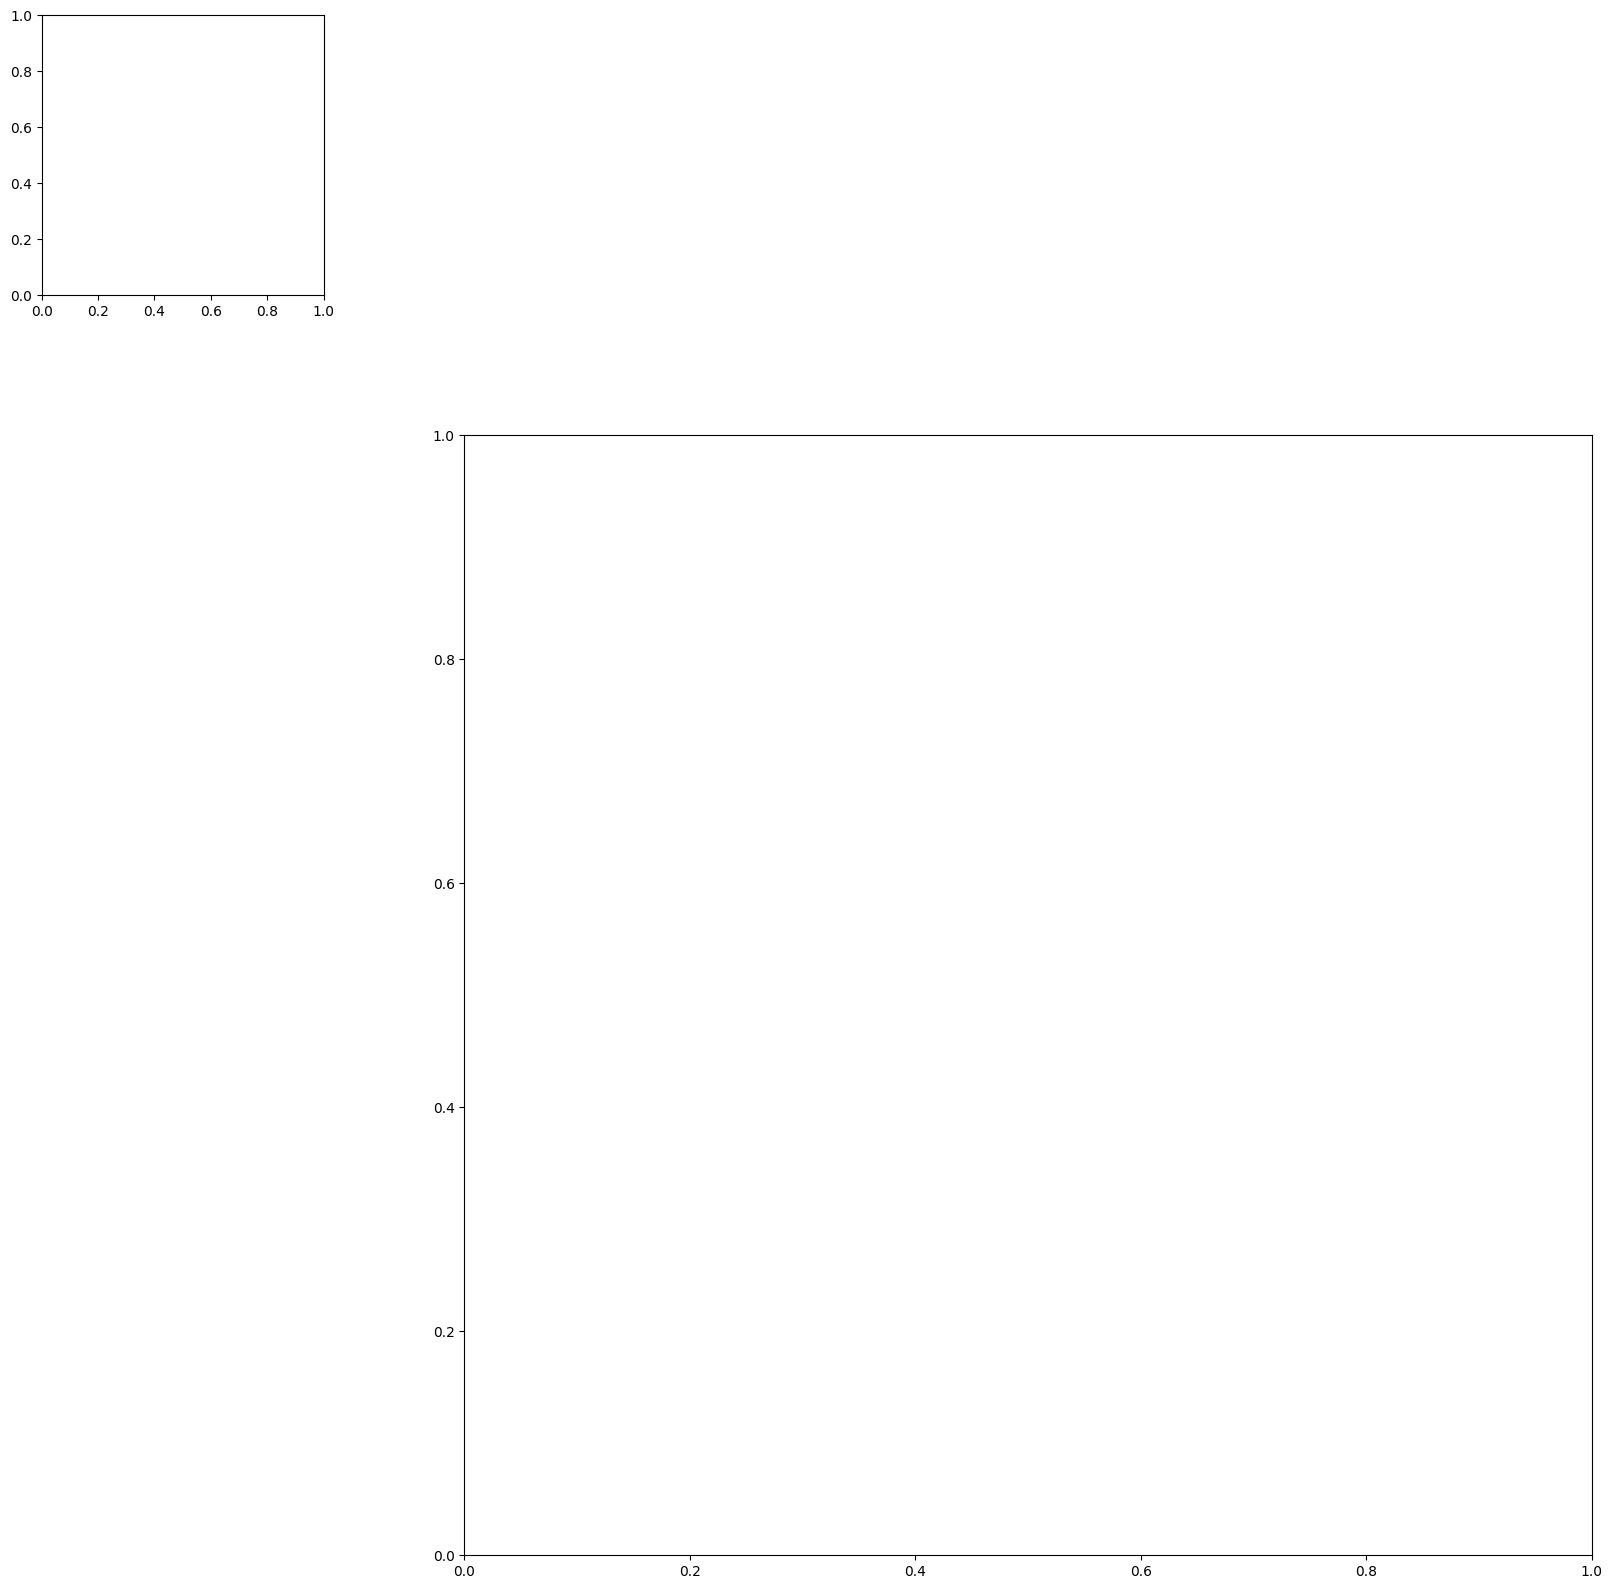

: 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# ----------------------------------------------------
# 2. Gerar o Clustermap
# ----------------------------------------------------
# Aumenta o tamanho da figura para melhor visualização
plt.figure(figsize=(20, 20))

# Cria o Clustermap. Ele faz o clustering e o heatmap em uma única linha!
sns.clustermap(corr_matrix_cleaned, 
               cmap="coolwarm",      # Paleta de cores para a correlação
               center=0,             # Centraliza a cor branca em 0 de correlação
               figsize=(20, 20)      # Define o tamanho total da figura
)

plt.suptitle("Clustermap da Matriz de Correlação", y=1.02, fontsize=20)
plt.show()